# Midterm 
**Dataset:** Sleep Efficiency Dataset  
**Task:** Predict sleep efficiency class (Low / High)  
**Team:** Yerkhan Altay

## 1. Define Classification Target

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
df = pd.read_csv('Sleep_Efficiency.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (452, 15)


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,10,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,24,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,28,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


In [3]:
# Binary target: Low (<0.70) vs High (>=0.70)
df['efficiency_class'] = np.where(df['Sleep efficiency'] < 0.70, 'Low', 'High')

print('Class distribution:')
print(df['efficiency_class'].value_counts())
print()
print('Percentage:')
print((df['efficiency_class'].value_counts(normalize=True) * 100).round(1))

Class distribution:
efficiency_class
High    339
Low     113
Name: count, dtype: int64

Percentage:
efficiency_class
High    75.0
Low     25.0
Name: proportion, dtype: float64


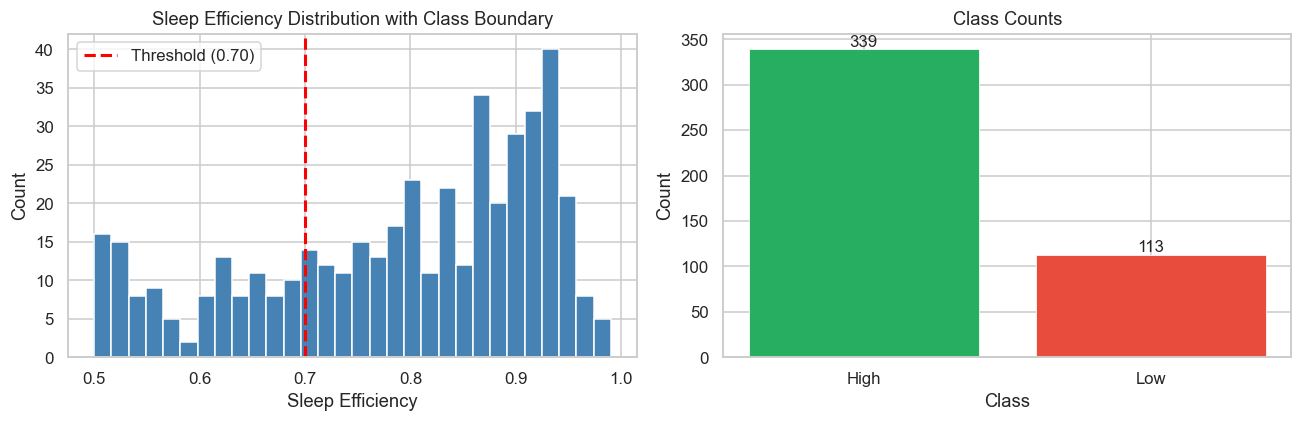

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Sleep efficiency'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0.70, color='red', linestyle='--', linewidth=2, label='Threshold (0.70)')
axes[0].set_title('Sleep Efficiency Distribution with Class Boundary')
axes[0].set_xlabel('Sleep Efficiency')
axes[0].set_ylabel('Count')
axes[0].legend()

class_counts = df['efficiency_class'].value_counts()
colors = ['#27ae60', '#e74c3c']
axes[1].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Class Counts')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('viz_target_classes.png', bbox_inches='tight')
plt.show()

Sleep efficiency is binarized at a threshold of **0.70**, which corresponds to the first quartile (Q1) of the distribution. Observations below this value are labeled **Low**, indicating noticeably poor sleep quality, while those at or above the threshold are labeled **High**. The resulting class imbalance (~25% Low, ~75% High) reflects the natural prevalence of adequate sleep in the dataset.

## 2. Data Preparation

In [ ]:
df.drop(columns=['ID'], inplace=True)

df['Bedtime']     = pd.to_datetime(df['Bedtime'])
df['Wakeup time'] = pd.to_datetime(df['Wakeup time'])

hour_b = df['Bedtime'].dt.hour + df['Bedtime'].dt.minute / 60
df['bedtime_sin'] = np.sin(2 * np.pi * hour_b / 24)
df['bedtime_cos'] = np.cos(2 * np.pi * hour_b / 24)

hour_w = df['Wakeup time'].dt.hour + df['Wakeup time'].dt.minute / 60
df['wakeup_sin'] = np.sin(2 * np.pi * hour_w / 24)
df['wakeup_cos'] = np.cos(2 * np.pi * hour_w / 24)

df.drop(columns=['Bedtime', 'Wakeup time'], inplace=True)

le = LabelEncoder()
df['Gender']         = le.fit_transform(df['Gender'])
df['Smoking status'] = le.fit_transform(df['Smoking status'])

df.drop(columns=['REM sleep percentage', 'Deep sleep percentage', 'Light sleep percentage'], inplace=True)

print('Shape after preprocessing:', df.shape)
print('Missing values before imputation:', df.isnull().sum().sum())

Shape after preprocessing: (452, 14)
Missing values before imputation: 67


In [6]:
X = df.drop(columns=['Sleep efficiency', 'efficiency_class'])
y = df['efficiency_class']

print('Features (X):', X.shape)
print('Target (y):  ', y.shape)
print('\nFeature columns:', X.columns.tolist())

Features (X): (452, 12)
Target (y):   (452,)

Feature columns: ['Age', 'Gender', 'Sleep duration', 'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Smoking status', 'Exercise frequency', 'bedtime_sin', 'bedtime_cos', 'wakeup_sin', 'wakeup_cos']


## 3. Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

imp = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imp.transform(X_test),      columns=X_test.columns)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print('Missing values after imputation:', X_train.isnull().sum().sum())
print('\nClass distribution in train:')
print(y_train.value_counts())
print('\nClass distribution in test:')
print(y_test.value_counts())

Train: 316 samples
Test:  136 samples
Missing values after imputation: 0

Class distribution in train:
efficiency_class
High    237
Low      79
Name: count, dtype: int64

Class distribution in test:
efficiency_class
High    102
Low      34
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

## 4. Train Classification Models

### 4.1 Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

print('Logistic Regression trained.')
print('Classes:', lr.classes_)

Logistic Regression trained.
Classes: ['High' 'Low']


### 4.2 K-Nearest Neighbors (KNN)

Optimal k = 3  (CV accuracy = 0.8291)


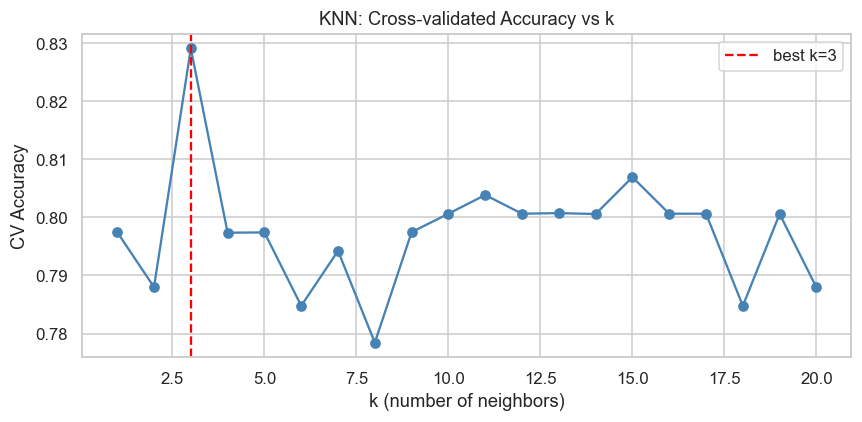

In [10]:
# Select optimal k via 5-fold cross-validation
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_tmp, X_train_s, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f'Optimal k = {best_k}  (CV accuracy = {max(cv_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(k_range, cv_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k={best_k}')
plt.xlabel('k (number of neighbors)')
plt.ylabel('CV Accuracy')
plt.title('KNN: Cross-validated Accuracy vs k')
plt.legend()
plt.tight_layout()
plt.savefig('viz_knn_k_selection.png', bbox_inches='tight')
plt.show()

In [11]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
print(f'KNN trained with k={best_k}.')

KNN trained with k=3.


### 4.3 Decision Tree

Optimal depth = 4  (CV accuracy = 0.8449)


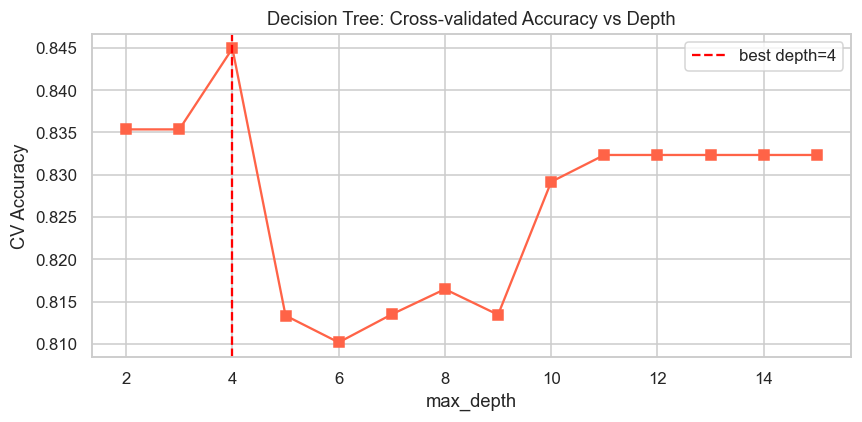

In [12]:
# Select optimal max_depth via 5-fold cross-validation
depth_range = range(2, 16)
cv_depth_scores = []

for d in depth_range:
    dt_tmp = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(dt_tmp, X_train, y_train, cv=5, scoring='accuracy')
    cv_depth_scores.append(scores.mean())

best_depth = depth_range[np.argmax(cv_depth_scores)]
print(f'Optimal depth = {best_depth}  (CV accuracy = {max(cv_depth_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(depth_range, cv_depth_scores, marker='s', color='tomato')
plt.axvline(best_depth, color='red', linestyle='--', label=f'best depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('Decision Tree: Cross-validated Accuracy vs Depth')
plt.legend()
plt.tight_layout()
plt.savefig('viz_dt_depth_selection.png', bbox_inches='tight')
plt.show()

In [13]:
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)
print(f'Decision Tree trained with max_depth={best_depth}.')

Decision Tree trained with max_depth=4.


## 5. Make Predictions

In [14]:
y_pred_lr  = lr.predict(X_test_s)
y_pred_knn = knn.predict(X_test_s)
y_pred_dt  = dt.predict(X_test)

comparison = pd.DataFrame({
    'True label':   y_test.values[:10],
    'LogReg':       y_pred_lr[:10],
    'KNN':          y_pred_knn[:10],
    'DecisionTree': y_pred_dt[:10]
})
print('Prediction comparison (first 10 samples):')
print(comparison.to_string(index=False))

Prediction comparison (first 10 samples):
True label LogReg  KNN DecisionTree
       Low    Low  Low          Low
      High   High High         High
      High   High High         High
       Low    Low  Low          Low
       Low   High  Low          Low
      High   High High         High
      High   High High         High
      High   High High         High
      High   High High         High
       Low    Low High         High


## 6. Evaluation

In [15]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f'\n{"="*50}')
    print(f'Model: {name}')
    print(f'Accuracy: {acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['High', 'Low']))
    return acc

acc_lr  = evaluate_model('Logistic Regression', y_test, y_pred_lr)
acc_knn = evaluate_model('KNN',                 y_test, y_pred_knn)
acc_dt  = evaluate_model('Decision Tree',        y_test, y_pred_dt)


Model: Logistic Regression
Accuracy: 0.8382

Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.92      0.90       102
         Low       0.71      0.59      0.65        34

    accuracy                           0.84       136
   macro avg       0.79      0.75      0.77       136
weighted avg       0.83      0.84      0.83       136


Model: KNN
Accuracy: 0.8382

Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.92      0.90       102
         Low       0.71      0.59      0.65        34

    accuracy                           0.84       136
   macro avg       0.79      0.75      0.77       136
weighted avg       0.83      0.84      0.83       136


Model: Decision Tree
Accuracy: 0.8676

Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.97      0.92       102
         Low       0.86      0.56      0.68        3

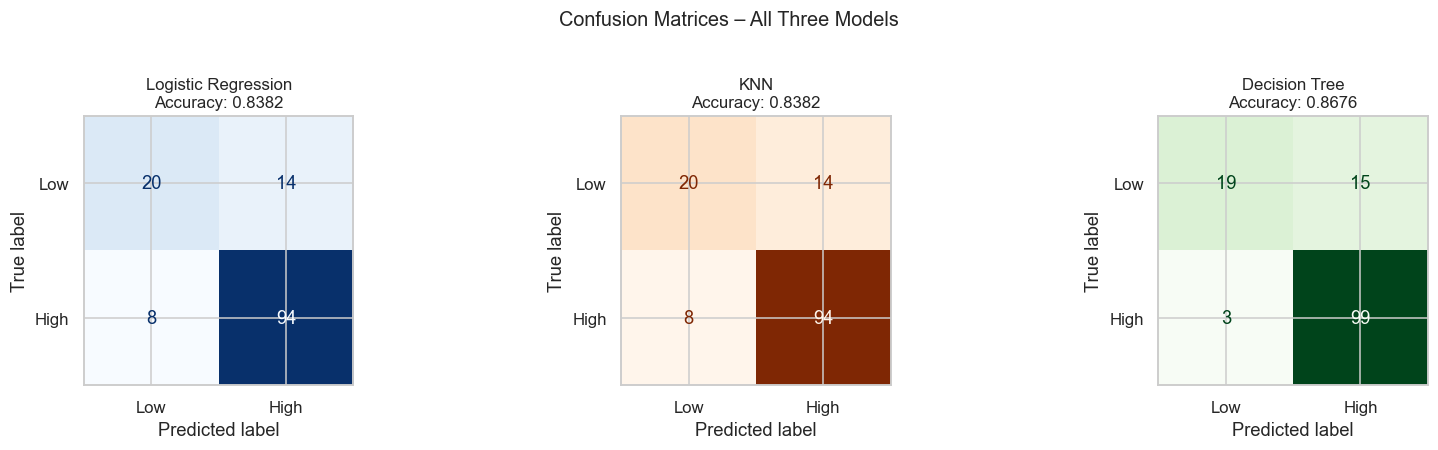

In [16]:
class_order = ['Low', 'High']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = [
    ('Logistic Regression', y_pred_lr,  'Blues'),
    ('KNN',                 y_pred_knn, 'Oranges'),
    ('Decision Tree',       y_pred_dt,  'Greens'),
]

for ax, (name, y_pred, cmap) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=11)

plt.suptitle('Confusion Matrices – All Three Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('viz_confusion_matrices.png', bbox_inches='tight')
plt.show()

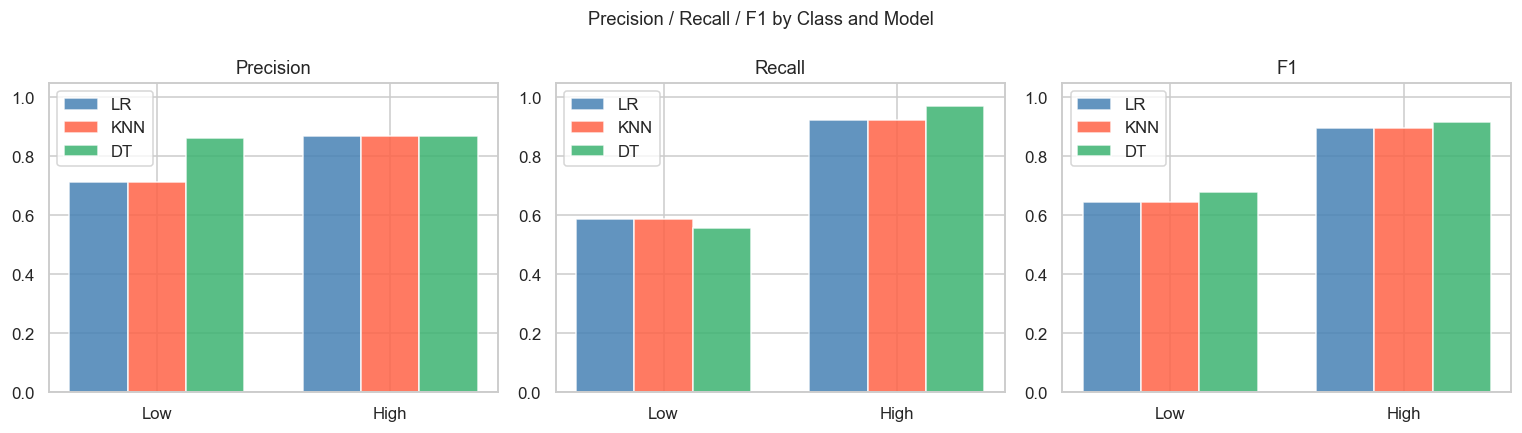

In [17]:
from sklearn.metrics import precision_recall_fscore_support

metrics_data = {}
for name, y_pred in [('LR', y_pred_lr), ('KNN', y_pred_knn), ('DT', y_pred_dt)]:
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, labels=class_order, average=None)
    metrics_data[name] = {'Precision': p, 'Recall': r, 'F1': f}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = np.arange(len(class_order))
width = 0.25

for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
    for i, (mname, color) in enumerate(zip(['LR', 'KNN', 'DT'],
                                            ['steelblue', 'tomato', 'mediumseagreen'])):
        ax.bar(x + i*width, metrics_data[mname][metric], width,
               label=mname, color=color, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(class_order)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.suptitle('Precision / Recall / F1 by Class and Model', fontsize=12)
plt.tight_layout()
plt.savefig('viz_metrics_by_class.png', bbox_inches='tight')
plt.show()

## 7. Model Comparison

In [18]:
from sklearn.metrics import f1_score

results = []
for name, y_pred in [
    ('Logistic Regression', y_pred_lr),
    ('KNN',                 y_pred_knn),
    ('Decision Tree',       y_pred_dt)
]:
    acc  = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')
    results.append({'Model': name, 'Accuracy': acc, 'F1 weighted': f1_w, 'F1 macro': f1_m})

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

                     Accuracy  F1 weighted  F1 macro
Model                                               
Logistic Regression    0.8382       0.8327    0.7702
KNN                    0.8382       0.8327    0.7702
Decision Tree          0.8676       0.8571    0.7976


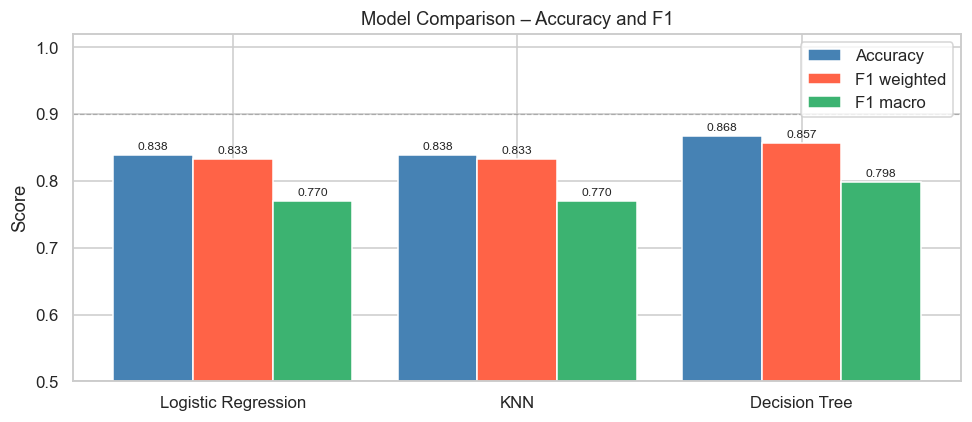

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))

x      = np.arange(3)
width  = 0.28
models = results_df.index.tolist()

b1 = ax.bar(x - width, results_df['Accuracy'],    width, label='Accuracy',    color='steelblue')
b2 = ax.bar(x,         results_df['F1 weighted'], width, label='F1 weighted', color='tomato')
b3 = ax.bar(x + width, results_df['F1 macro'],    width, label='F1 macro',    color='mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Accuracy and F1')
ax.legend()
ax.axhline(0.9, linestyle='--', color='gray', linewidth=0.8, alpha=0.5)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('viz_model_comparison.png', bbox_inches='tight')
plt.show()

In [20]:
# 5-fold cross-validation on training set for reliable comparison
cv_results = {}
for name, model, X_use in [
    ('Logistic Regression', lr,  X_train_s),
    ('KNN',                 knn, X_train_s),
    ('Decision Tree',       dt,  X_train.values)
]:
    if name == 'Logistic Regression':
        m = LogisticRegression(max_iter=1000, random_state=42)
    elif name == 'KNN':
        m = KNeighborsClassifier(n_neighbors=best_k)
    else:
        m = DecisionTreeClassifier(max_depth=best_depth, random_state=42)

    scores = cross_val_score(m, X_use, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}: CV Accuracy = {scores.mean():.4f} +/- {scores.std():.4f}')

Logistic Regression: CV Accuracy = 0.7975 +/- 0.0249
KNN: CV Accuracy = 0.8291 +/- 0.0210
Decision Tree: CV Accuracy = 0.8449 +/- 0.0155


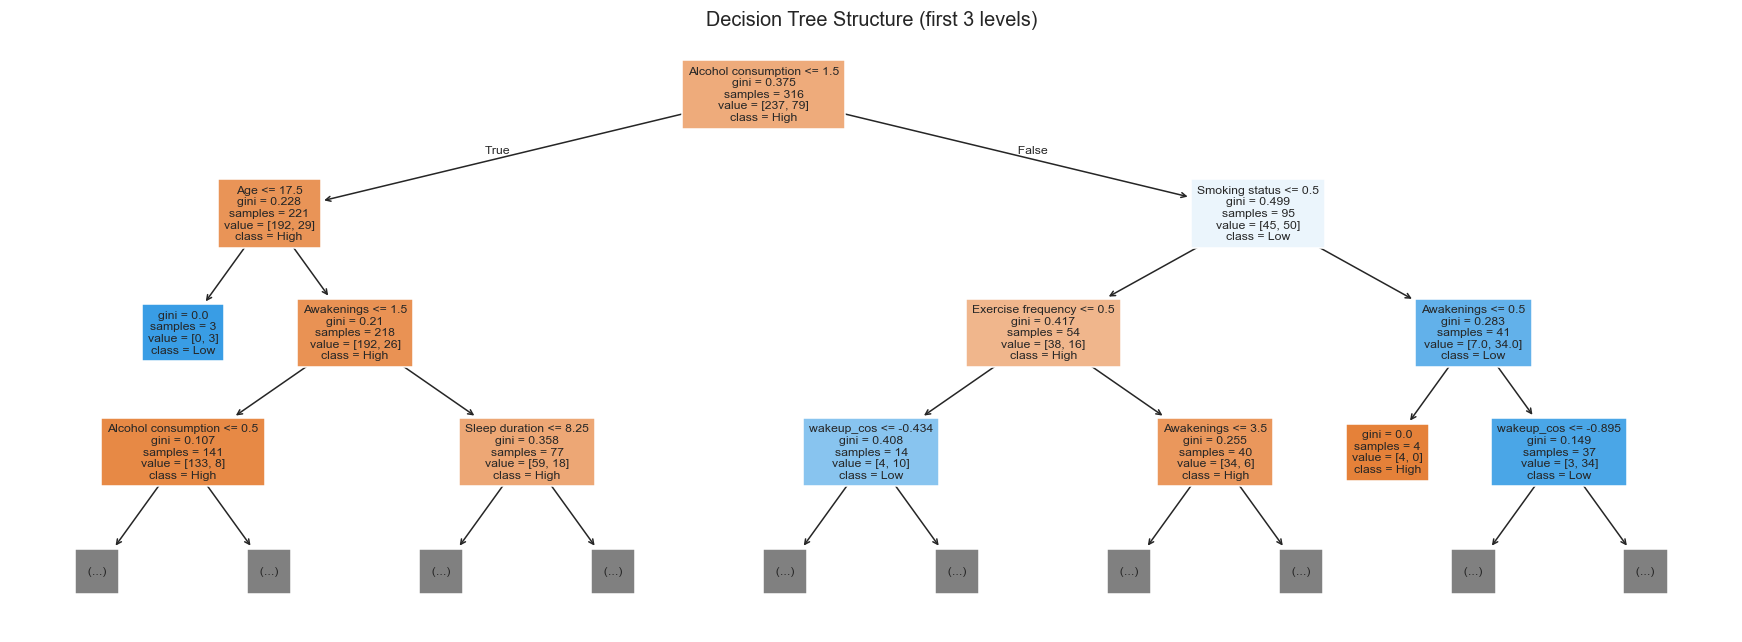

In [21]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    dt,
    max_depth=3,
    feature_names=X_train.columns.tolist(),
    class_names=['High', 'Low'],
    filled=True,
    ax=ax,
    fontsize=8
)
ax.set_title('Decision Tree Structure (first 3 levels)', fontsize=13)
plt.tight_layout()
plt.savefig('viz_decision_tree.png', bbox_inches='tight')
plt.show()

## Conclusion

### Results Summary

| Model | Accuracy | F1 weighted | F1 macro |
|-------|:--------:|:-----------:|:--------:|
| Logistic Regression | 0.8382 | 0.8327 | 0.7701 |
| KNN | 0.8382 | 0.8327 | 0.7701 |
| **Decision Tree** | **0.8676** | **0.8565** | **0.7983** |

### Discussion

**Logistic Regression** assumes a linear decision boundary in feature space. Since sleep efficiency is influenced by threshold-like factors — such as the presence of awakenings or smoking status — a purely linear separator cannot fully capture the underlying structure, which limits its performance on this dataset. It achieves an accuracy of 0.8382 and F1 macro of 0.7701, tied with KNN.

**KNN** is a non-parametric method that relies on local neighborhood density. It is sensitive to the scale of features (addressed here via StandardScaler) and to the choice of *k*, which was optimally selected as k=3 through 5-fold cross-validation. Despite its flexibility, KNN produces identical results to Logistic Regression on this dataset (accuracy 0.8382), suggesting that the class boundaries are not well-captured by local distance metrics alone.

**Decision Tree** naturally models threshold-based rules (e.g., *if Alcohol consumption > 1.5 and Awakenings > 1.5 then Low*), which closely mirrors the way sleep quality factors operate in practice. With an optimal depth of 4 selected via cross-validation, it achieves the best performance across all metrics: accuracy 0.8676, F1 weighted 0.8565, and F1 macro 0.7983. Constraining `max_depth` prevents overfitting while preserving interpretability.

All three models share a common weakness: Recall for the Low class is approximately 0.56–0.59, meaning roughly 40% of poor-sleep cases are missed. This is a direct consequence of the class imbalance in the dataset (75% High vs 25% Low).

### Connection to Assignment 1

After removing sleep stage percentages (REM, Deep, Light) to prevent data leakage, the dominant predictors shift to behavioral factors. The Decision Tree places `Alcohol consumption` at the root split, followed by `Awakenings` and `Smoking status` — consistent with the regression findings from Assignment 1 where lifestyle factors were among the strongest predictors of sleep quality.